In [ ]:
!pip install anthropic

In [ ]:
import os
from anthropic import Anthropic

client = Anthropic(
    api_key=os.environ.get("ANTHROPIC_API_KEY"),  # reads from the env var you just set
)

message = client.messages.create(
    model="claude-sonnet-5",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": "Hello, Claude! Give me a one-sentence fun fact."}
    ],
)

print(message.content[0].text)

In [ ]:
!pip install python-dotenv

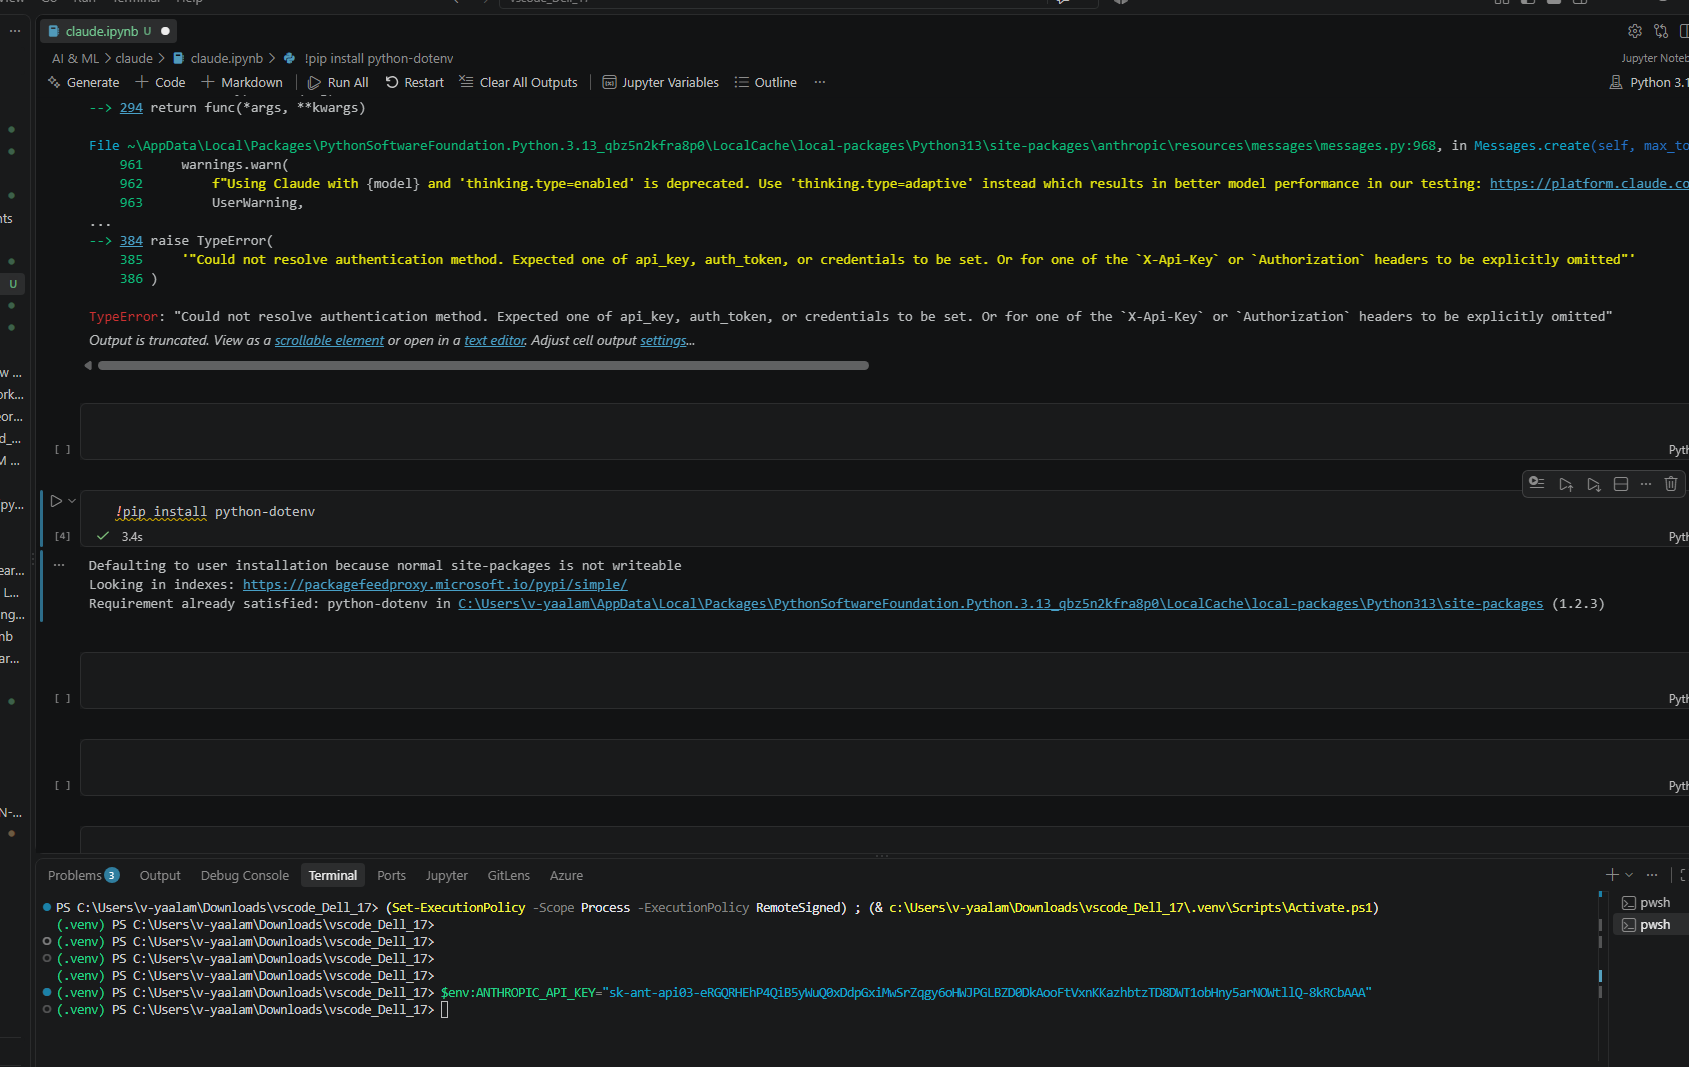


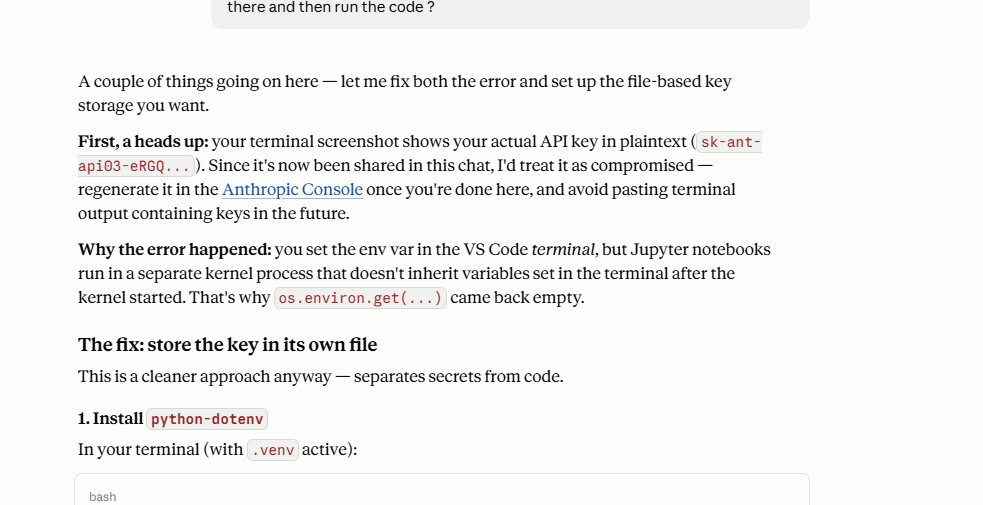



In [ ]:
import os
from dotenv import load_dotenv
from anthropic import Anthropic

# Loads variables from the .env file into the environment
load_dotenv()

client = Anthropic(
    api_key=os.environ.get("ANTHROPIC_API_KEY"),
)

message = client.messages.create(
    model="claude-sonnet-5",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": "Hello, Claude! Give me a one-sentence fun fact."}
    ],
)

print(message.content[0].text)

A couple of things going on here — let me fix both the error and set up the file-based key storage you want.

**First, a heads up:** your terminal screenshot shows your actual API key in plaintext (``). Since it's now been shared in this chat, I'd treat it as compromised — regenerate it in the [Anthropic Console](https://console.claude.com/settings/keys) once you're done here, and avoid pasting terminal output containing keys in the future.

**Why the error happened:** you set the env var in the VS Code *terminal*, but Jupyter notebooks run in a separate kernel process that doesn't inherit variables set in the terminal after the kernel started. That's why `os.environ.get(...)` came back empty.

## The fix: store the key in its own file

This is a cleaner approach anyway — separates secrets from code.

### 1. Install `python-dotenv`

In your terminal (with `.venv` active):
```bash
pip install python-dotenv
```

### 2. Create a `.env` file

In the same folder as your notebook, create a file named exactly `.env` (no extension) with this content:

```
ANTHROPIC_API_KEY=your-new-api-key-here
```

### 3. (Important) Keep it out of version control

If this folder is a git repo, create/edit `.gitignore` and add:
```
.env
```

### 4. Update your notebook cell

```python
import os
from dotenv import load_dotenv
from anthropic import Anthropic

# Loads variables from the .env file into the environment
load_dotenv()

client = Anthropic(
    api_key=os.environ.get("ANTHROPIC_API_KEY"),
)

message = client.messages.create(
    model="claude-sonnet-5",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": "Hello, Claude! Give me a one-sentence fun fact."}
    ],
)

print(message.content[0].text)
```

### 5. Restart the kernel

Since the kernel already started without the key, click **Restart** in the notebook toolbar, then run the cell again from the top.

A couple of notes:
- `load_dotenv()` looks for `.env` in the current working directory (or parent folders) — make sure the notebook's working directory matches where you saved `.env`.
- You can verify the key loaded correctly by temporarily running `print(os.environ.get("ANTHROPIC_API_KEY")[:10])` — just remove it afterward so you're not printing key fragments unnecessarily.

In [ ]:
message = client.messages.create(
    model="claude-haiku-4-5",   # cheaper & faster than Sonnet
    max_tokens=200,             # lower token cap = lower cost per request
    messages=[
        {"role": "user", "content": "Hello, Claude! Give me a one-sentence fun fact."}
    ],
)

print(message.content[0].text)